## Stationarity test

Stationarity- It shows the mean value of the series that remains constant over the time period. If past effects accumulate and the values increase towards infinity then stationarity is not met.

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

https://hex.tech/blog/stationarity-in-time-series/#:~:text=The%20KPSS%20test%20is%20another,the%20null%20hypothesis%2C%20indicating%20stationarity.

We use Augmented Dickey-Fuller (ADF) test to check the stationarity of the Time Series
H0: None stationary (unit root)
H1: Time Series is Stationare

In [2]:
data_needed = ["Order Date", "Purchase Price Per Unit", "Quantity", "Category", "Survey ResponseID", "Shipping Address State", "ppt", "tmin", "tmax", "tavg"]

transactions_temp = pd.read_csv("./Data/data_combined.csv", usecols=data_needed)

In [3]:
# Lists for Cat filter
Fashion = [
    "ACCESSORY", "ADULT_COSTUME", "APPAREL", "APPAREL_BELT", "APPAREL_GLOVES",
    "APPAREL_HEAD_NECK_COVERING", "APPAREL_PIN", "APPENDAGE_WARMER", "APRON",
    "ARM_SLEEVE", "Apparel", "BABY_JUMPER_WALKER", "BELTS", "BLAZER",
    "BLUE_LIGHT_BLOCKING_EYEGLASSES", "BODYSTOCKING", "BOOT", "BRA", "BRACELET",
    "BRA_UNDERWEAR_SET", "CHOLI", "COAT", "COORDINATED_OUTFIT", "CORRECTIVE_EYEGLASSES",
    "CORSET", "DRESS", "DUPATTA", "EARMUFF", "EARRING", "ETHNIC_WEAR",
    "FASHIONEARRING", "FASHIONNECKLACEBRACELETANKLET", "FASHIONOTHER", "FASHIONRING",
    "FASHION_JEWELRY", "FINEEARRING", "FINENECKLACEBRACELETANKLET", "FINERING",
    "FOOTWEAR", "GUILD_APPAREL", "GUILD_JEWELRY", "GUILD_SHOES", "HAT", "HOSIERY",
    "JEWELRY", "JEWELRY_SET", "KIMONO", "KURTA", "LEG_SLEEVE", "LEOTARD",
    "MOISTURIZING_SOCK_GLOVE", "NECKLACE", "NECKTIE", "NIGHTGOWN_NIGHTSHIRT",
    "ORCA_SHIRT", "OUTERWEAR", "OVERALLS", "PAJAMAS", "PANTS", "PIERCING_JEWELRY",
    "ROBE", "SANDAL", "SAREE", "SHIRT", "SHOES", "SHORTS", "SKIRT", "SLEEPWEAR",
    "SLIPPER", "SNOWSHOE", "SNOWSUIT", "SNOW_PANT", "SOCK", "SOCKSHOSIERY", "SUIT",
    "SUNGLASSES", "SUSPENDER", "SWEATER", "SWEATSHIRT", "SWIMWEAR", "SWIM_CAP",
    "TIGHTS", "TRACK_SUIT", "UNDERPANTS", "UNDERWEAR", "UNDERGARMENT_SLIP",
    "UNDERGARMENT_THIGH_SLIMMER", "UNION_SUIT", "VEST", "WATCH", "WATCHES", "WATCH_BAND"
]


Groceries = [
   "ALCOHOLIC_BEVERAGE", "BABY_FOOD", "BABY_FORMULA", "BAKING_CHOCOLATE", "BEER",
   "BEVERAGE", "BREAD", "BREAKFAST_CEREAL", "CAKE", "CANDY", "CEREAL",
   "CHOCOLATE_CANDY", "COFFEE", "CONDIMENT", "COOKIE", "CRACKER", "CULINARY_SALT",
   "DAIRY_BASED_BUTTER", "DAIRY_BASED_CHEESE", "DAIRY_BASED_CREAM",
   "DAIRY_BASED_DRINK", "DAIRY_BASED_ICE_CREAM", "DAIRY_BASED_PUDDING",
   "DAIRY_BASED_YOGURT", "DONUT", "DRINK_FLAVORED", "EDIBLE_OIL_VEGETABLE",
   "FLOUR", "FRUIT", "FRUIT_SNACK", "FUDGE", "GOURMET_FOOD", "GROCERY", "Grocery",
   "HEALTH_FOOD", "HONEY", "JERKY", "JUICE_AND_JUICE_DRINK", "LEGUME",
   "MEAL_REPLACEMENT_BEVERAGE", "MEAT_ALTERNATIVE", "MILK_SUBSTITUTE",
   "NON_DAIRY_CHEESE", "NON_DAIRY_CREAM", "NON_DAIRY_ICE_CREAM",
   "NON_DAIRY_PUDDING", "NON_DAIRY_YOGURT", "NOODLE", "NUTS", "NUT_AND_SEED",
   "NUT_BUTTER", "OLIVE", "PACKAGED_SOUP_AND_STEW", "PASTRY", "POPCORN",
   "PRETZEL", "PROTEIN_DRINK", "PROTEIN_SUPPLEMENT_POWDER", "PUFFED_SNACK",
   "RICE_MIX", "RICE_WINE", "SALAD_DRESSING", "SEAFOOD", "SEASONING",
   "SNACK_CHIP_AND_CRISP", "SNACK_FOOD", "SNACK_FOOD_BAR", "SNACK_MIX",
   "SPORTS_DRINK", "SUGAR", "SUGAR_CANDY", "SUGAR_SUBSTITUTE", "SYRUP", "TEA",
   "TOFU", "VEGETABLE", "VEGETARIAN_EGG_SUBSTITUTE", "WATER"
]

In [4]:
transactions_temp = transactions_temp[(transactions_temp['Order Date'] < '2022-01-01')]

In [5]:
# Filter for only Fashion and Groceries
mask_cat = transactions_temp["Category"].isin(Fashion) | transactions_temp["Category"].isin(Groceries)
data_filtered = transactions_temp[mask_cat]
CA_only = data_filtered[data_filtered["Shipping Address State"].isin(["CA"])] # filter for CA
CA_only = CA_only.sort_values(["Order Date"]).copy()

In [6]:
CA_only["Revenue"] = CA_only["Purchase Price Per Unit"] * CA_only["Quantity"]

In [7]:
# Calculate the total revenue per each day
CA_only = CA_only.groupby(["Order Date"]).agg({"Revenue": "sum", "tavg": "first"}).round(2)

# Stationarity test
### Raw Revenue data

In [8]:
Revenue = CA_only["Revenue"]

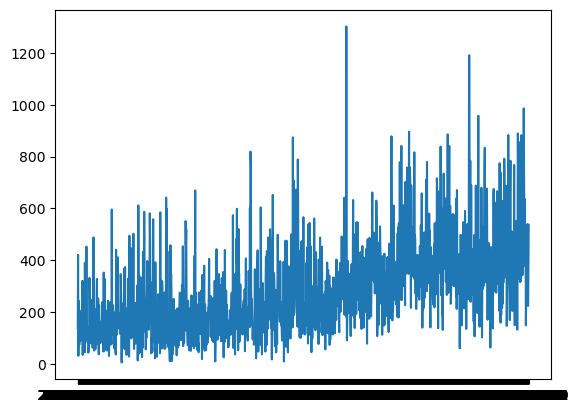

In [9]:
# Quick plot
plt.plot(Revenue)
plt.show()

In [10]:
adf_result = adfuller(Revenue)

In [11]:
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -3.4273164051475855
P-value: 0.010062166025507076


### SMA 7

In [12]:
CA_SMA = CA_only
CA_SMA["Revenue_SMA7"] = CA_only["Revenue"].rolling(7).mean()

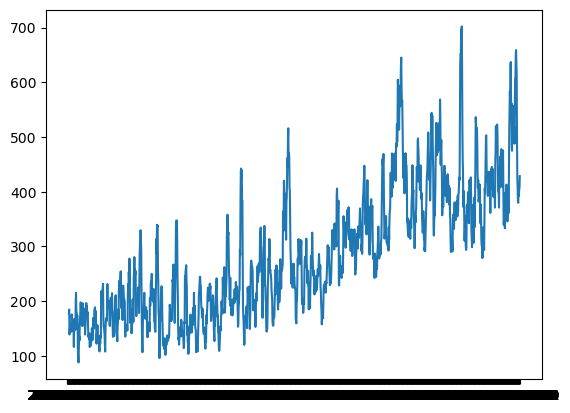

In [13]:
# Quick plot
plt.plot(CA_SMA["Revenue_SMA7"])
plt.show()

In [14]:
CA_SMA_sliced = CA_SMA.iloc[6:,:]

In [15]:
adf_result = adfuller(CA_SMA_sliced["Revenue_SMA7"])

In [16]:
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -2.080947651705463
P-value: 0.2522443307979826


### SMA 30

In [17]:
CA_SMA = CA_only
CA_SMA["Revenue_SMA30"] = CA_only["Revenue"].rolling(30).mean()

CA_SMA_sliced = CA_SMA.iloc[29:,:]

In [18]:
adf_result = adfuller(CA_SMA_sliced["Revenue_SMA30"])
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -1.8091165491499859
P-value: 0.3759450655835235


In [19]:
if p_value <= 0.05:
	print('Reject the null hypothesis: The time series is stationary.')
else:
	print('Fail to reject the null hypothesis: The time series is non-stationary.')

Fail to reject the null hypothesis: The time series is non-stationary.


## First order difference
Rev(t) - Rev(t-1)

In [20]:
first_order_diff = [0]
#first_order_diff.append(0)

for i in range(1,len(CA_only)): 
    #CA_only["first_order_diff"][i] = CA_only["Revenue"][i] - CA_only["Revenue"][i-1]
    first_order_diff.append(CA_only["Revenue"][i] - CA_only["Revenue"][i-1])

CA_only["first_oder_diff"] = first_order_diff

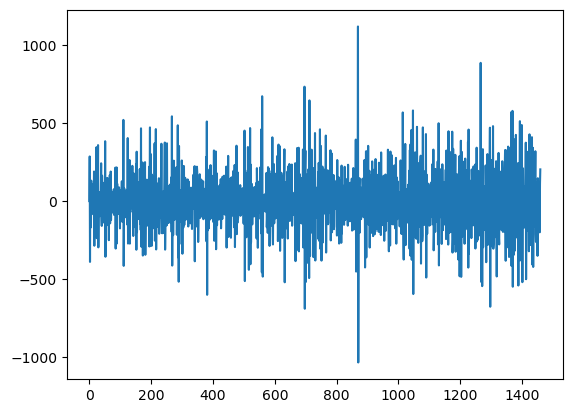

In [21]:
plt.plot(first_order_diff)
plt.show()

In [22]:
adf_result = adfuller(first_order_diff)
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -14.062001119173507
P-value: 3.044821257592347e-26


## Finding and adjusting for the Trend in the timeseries

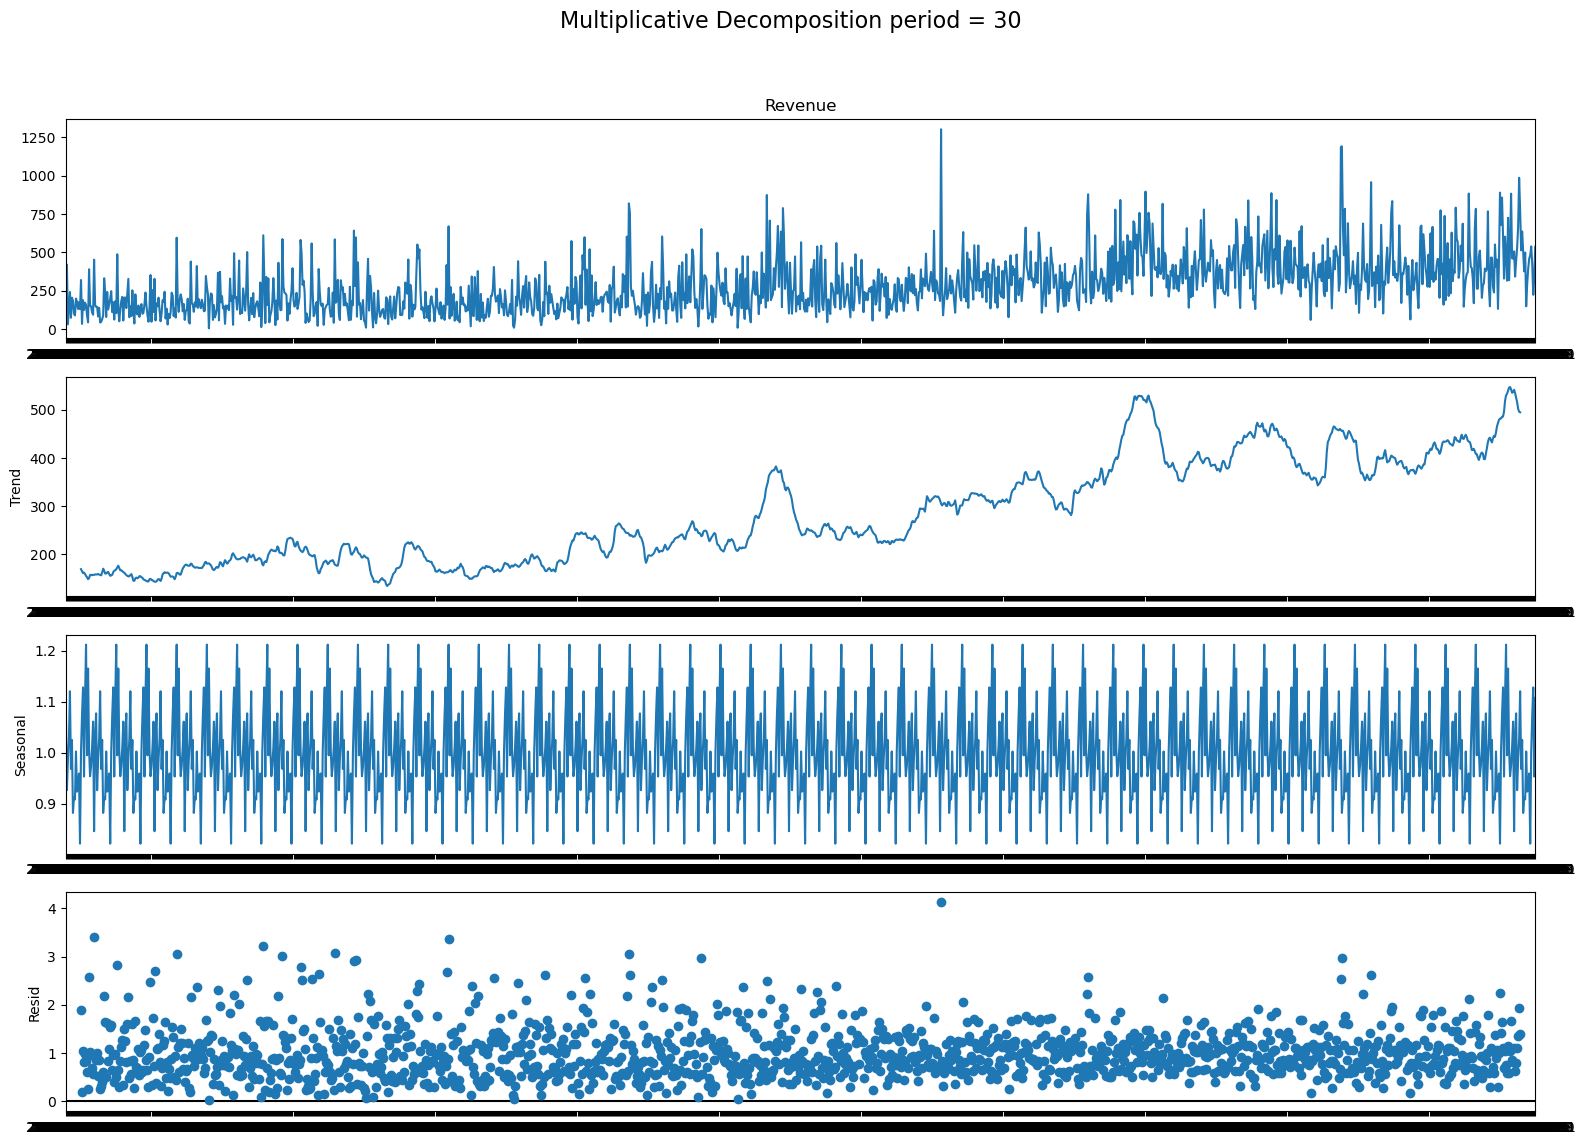

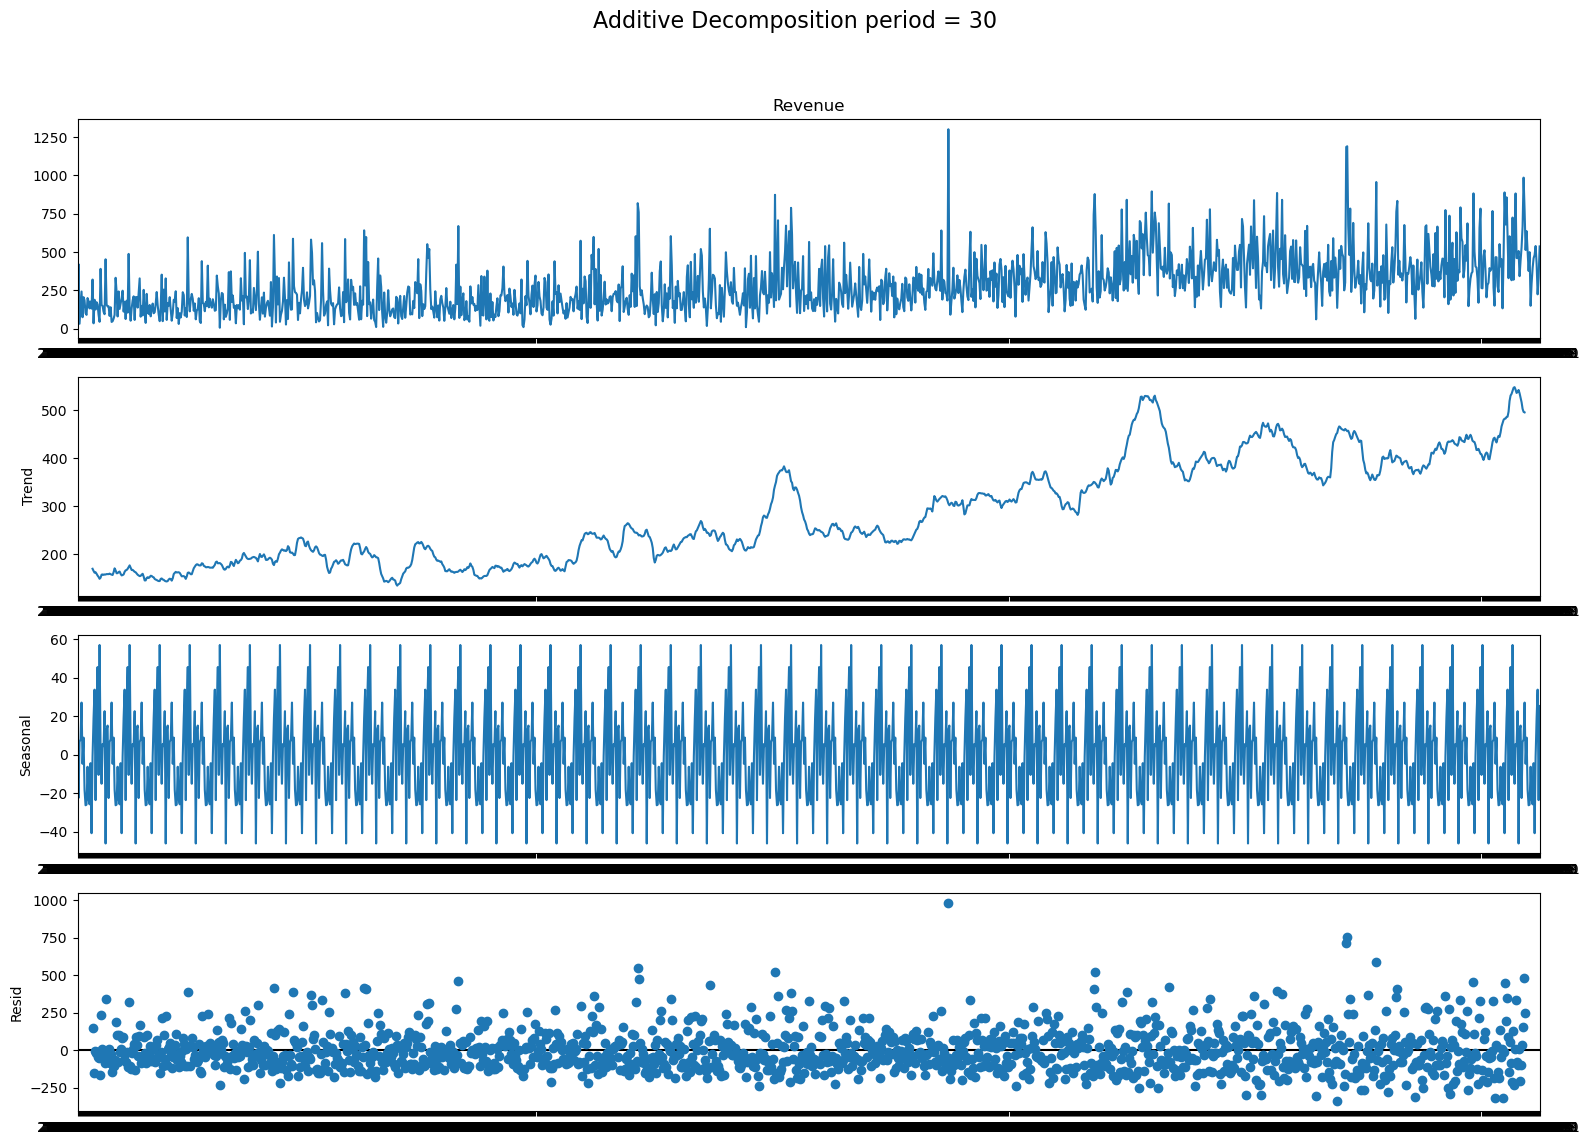

In [23]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 30', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 30', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

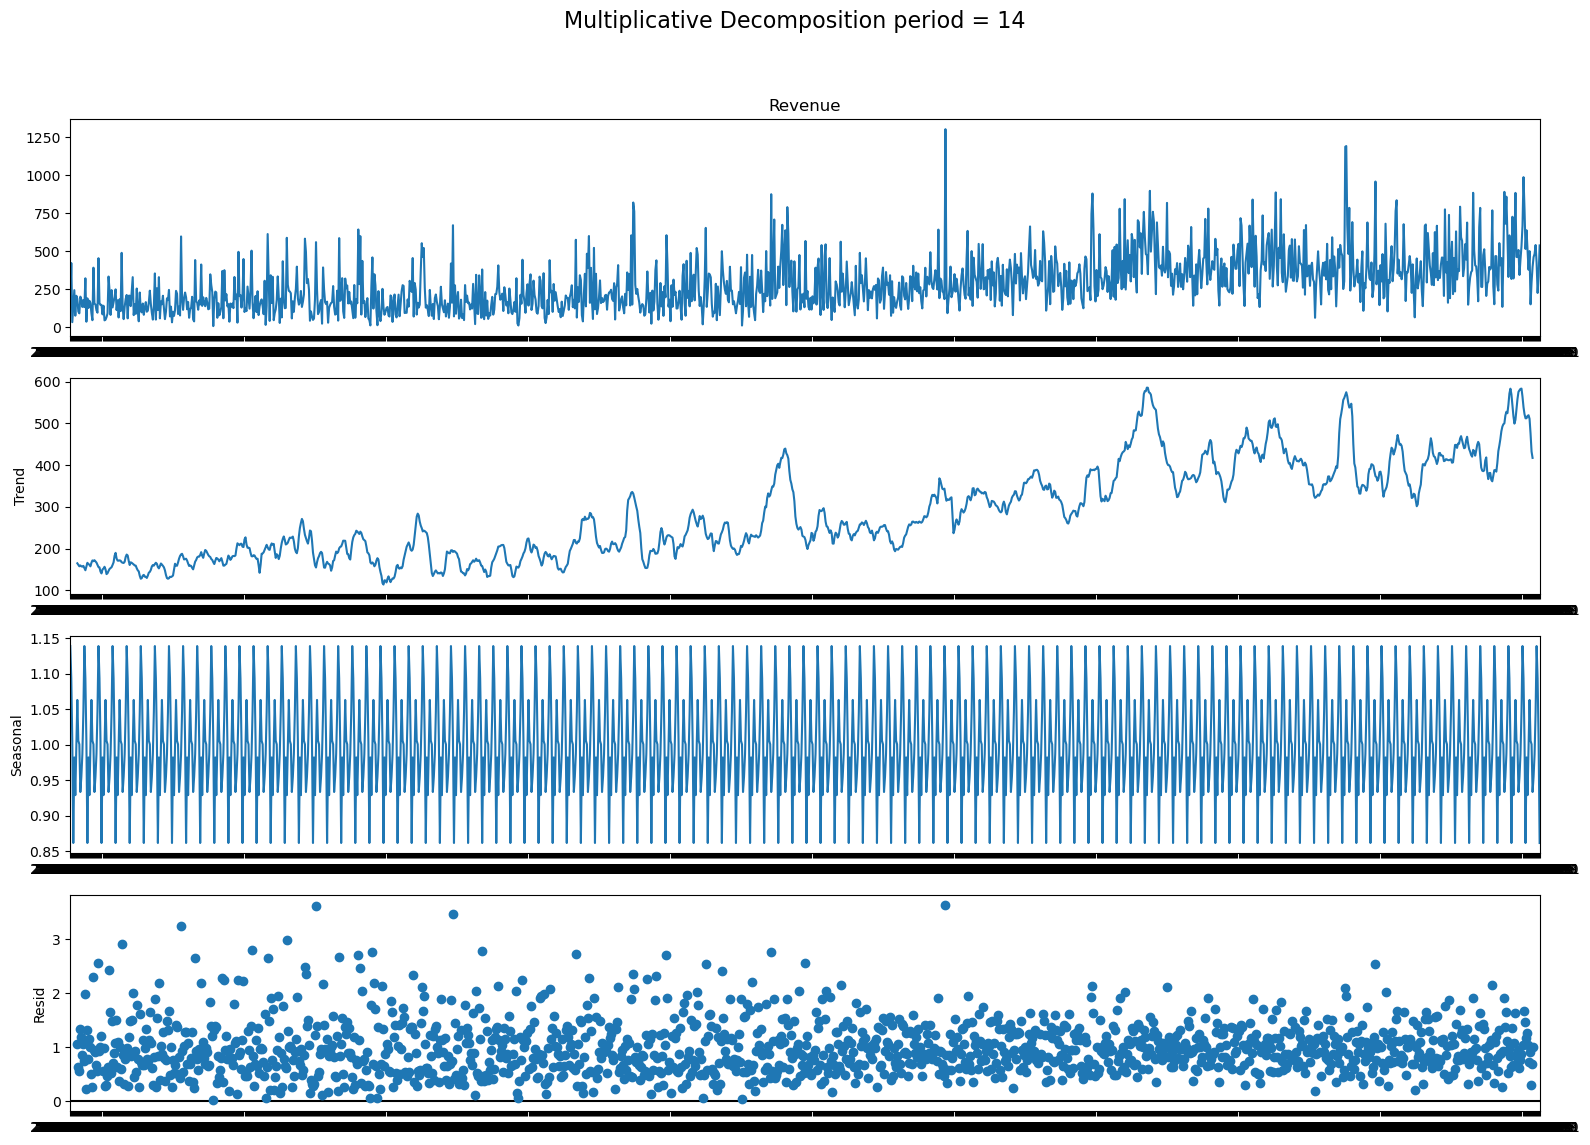

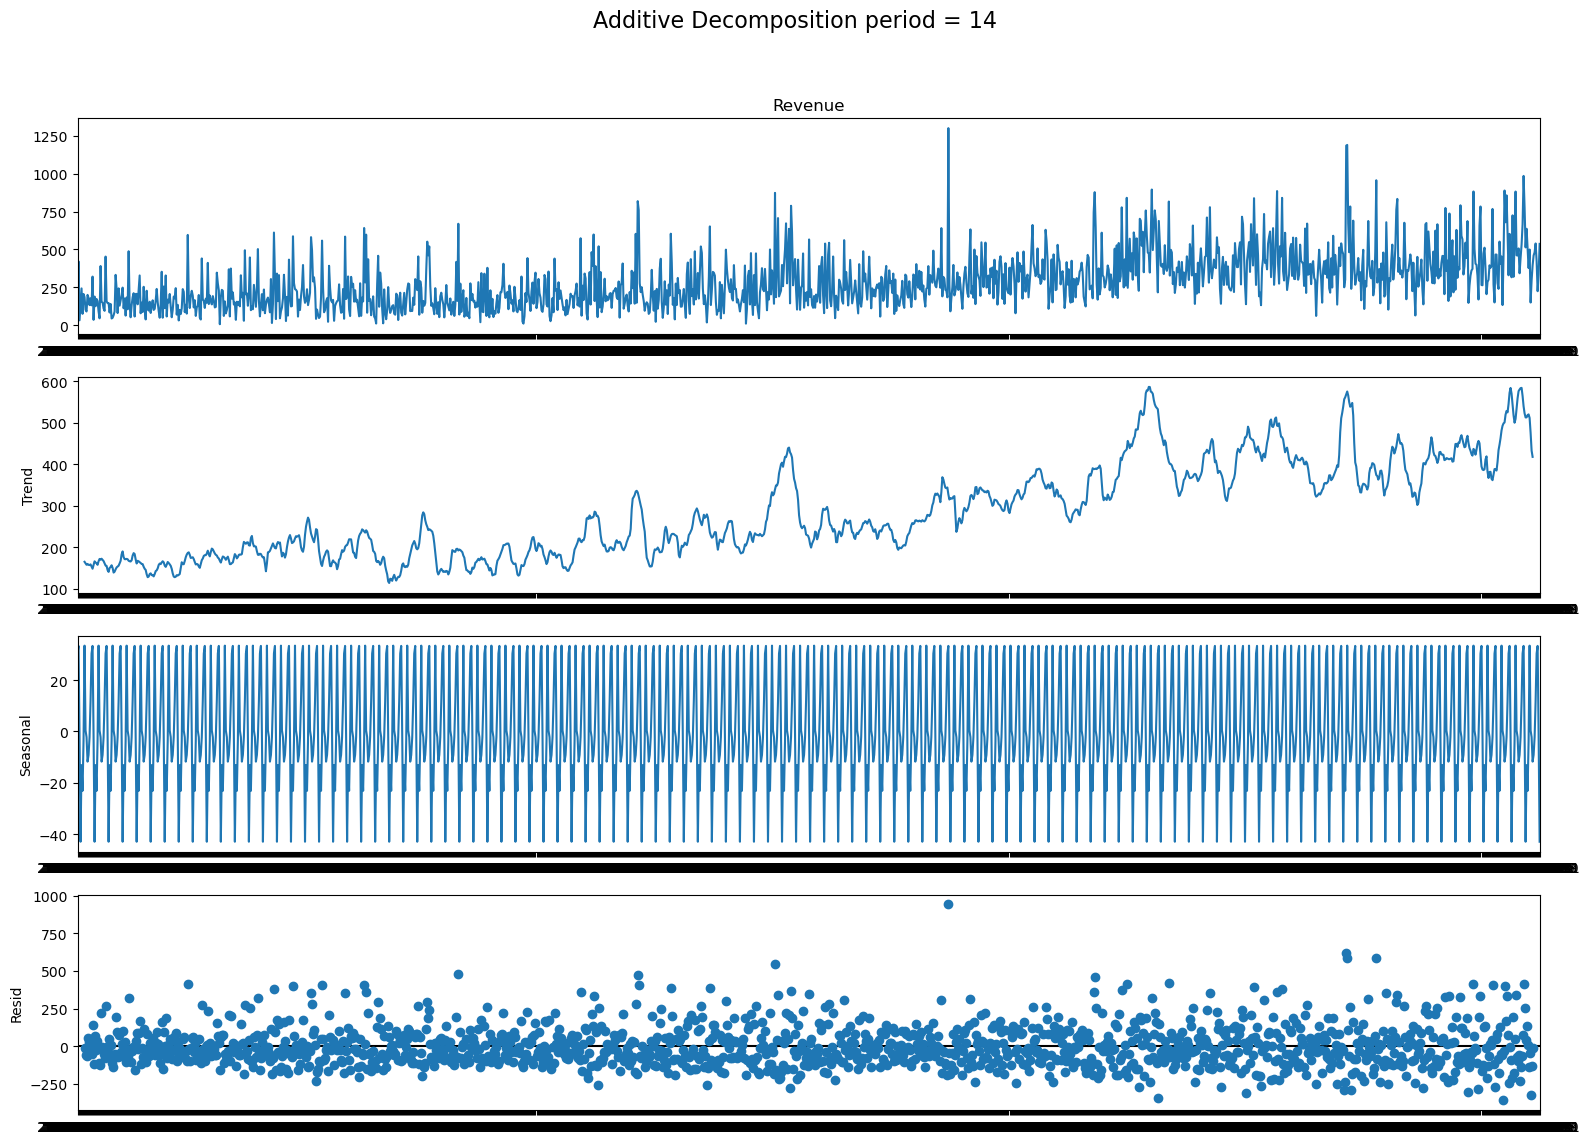

In [24]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=14)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=14)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 14', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 14', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

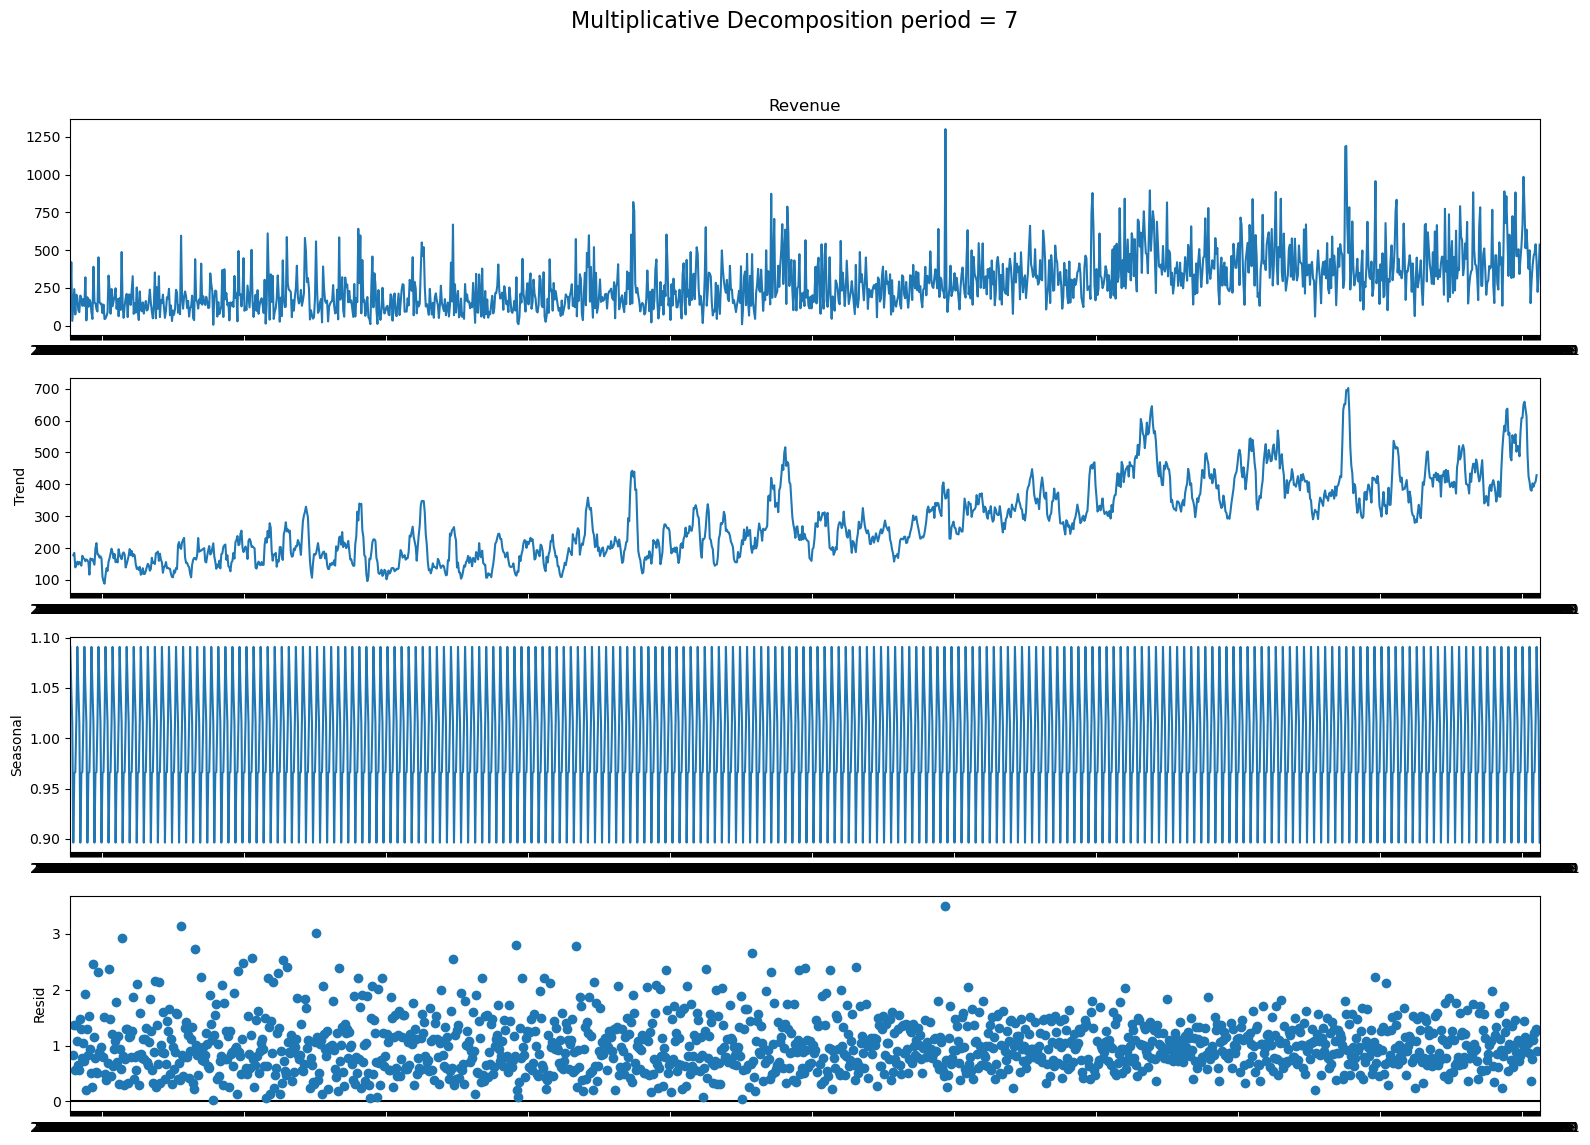

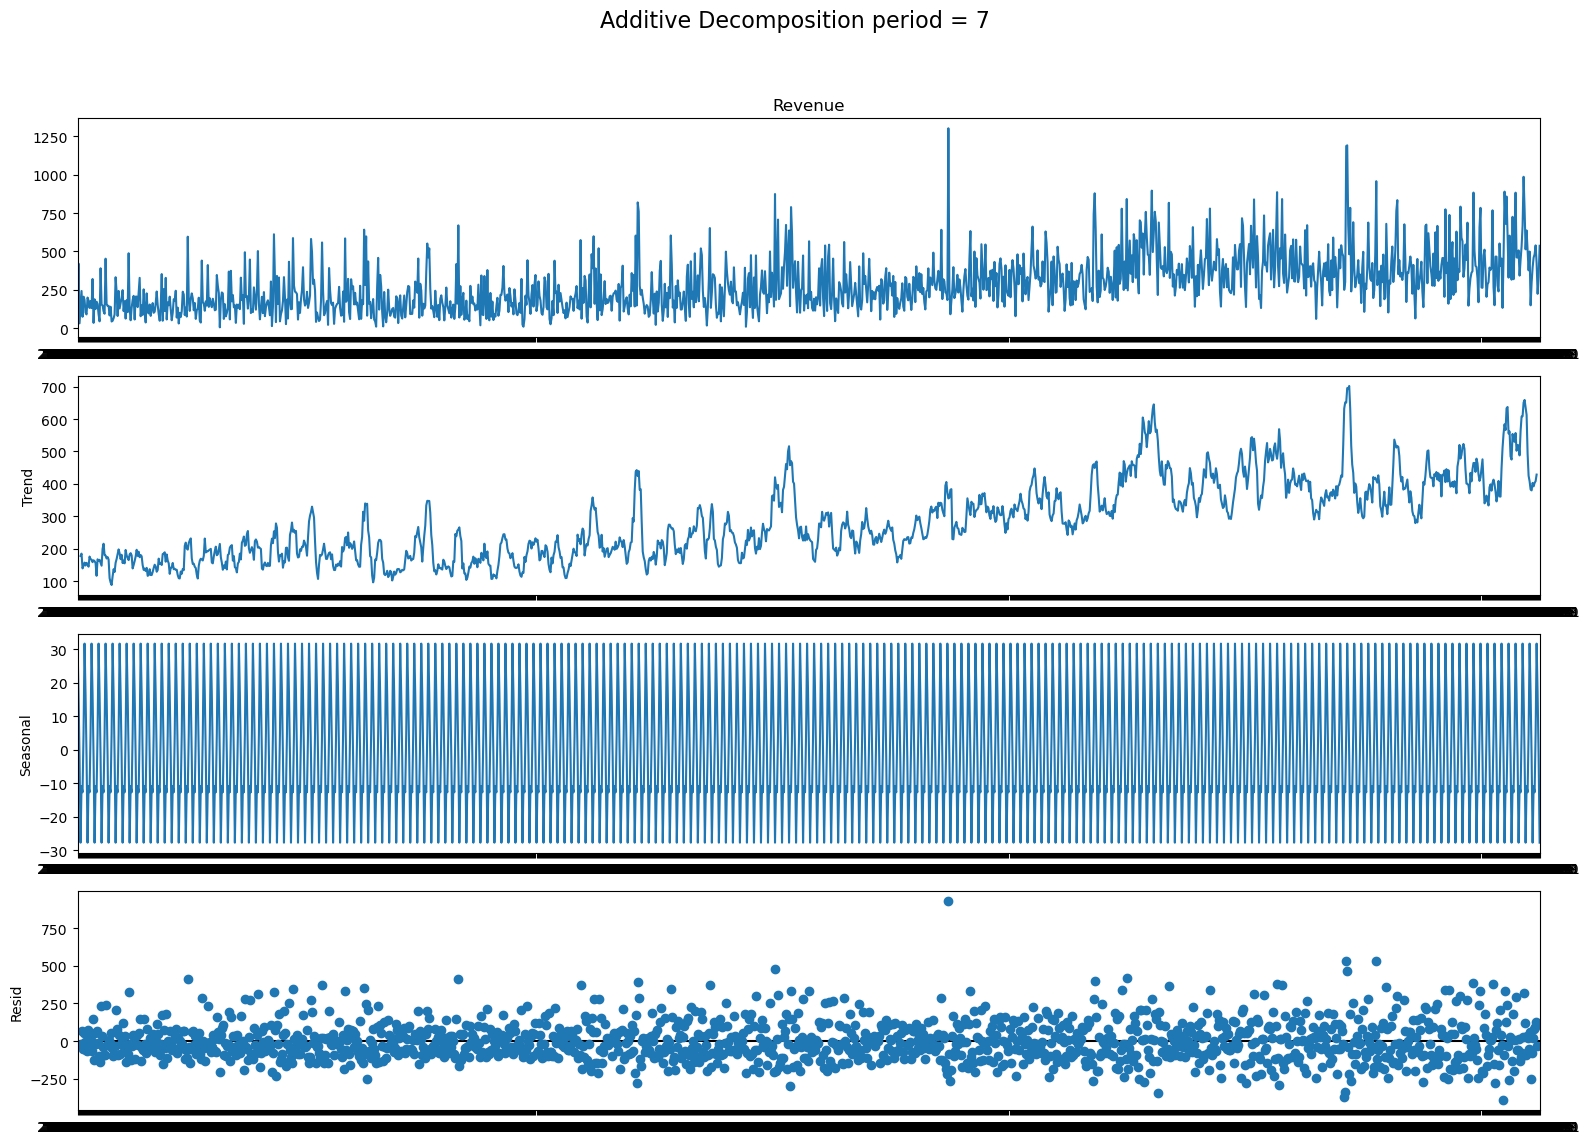

In [25]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=7)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=7)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 7', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 7', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Analysis of the Plots using Claude AI: 

#### Period = 30 days (Images 1 & 2):
Strong seasonal pattern with clear monthly cycles
Smoother trend component
Multiplicative model shows more consistent residuals compared to additive
Seasonal factors range from 0.85 to 1.2 (multiplicative) vs -40 to +60 (additive)


#### Period = 14 days (Images 3 & 4):
Bi-weekly patterns become visible
Trend line becomes slightly more volatile
Seasonal patterns are more frequent but still regular
Multiplicative decomposition maintains better residual stability


#### Period = 7 days (Images 5 & 6):
Weekly patterns are now visible
Trend component becomes more volatile
Seasonal patterns are very frequent
Residuals remain more stable in multiplicative model

Key Observations:

The multiplicative model appears superior across all periods because:

More consistent residual patterns regardless of the revenue level
Better handling of the increasing variance in the data
More stable seasonal factors


Period Selection:

Period = 30 shows the cleanest decomposition with:

Smoothest trend component
Clear seasonal patterns
Well-behaved residuals


Shorter periods (14, 7) introduce more noise in the trend component

### Detrending Revenue

Text(0.5, 1.0, 'Daily Revenue detrended by subtracting the trend component')

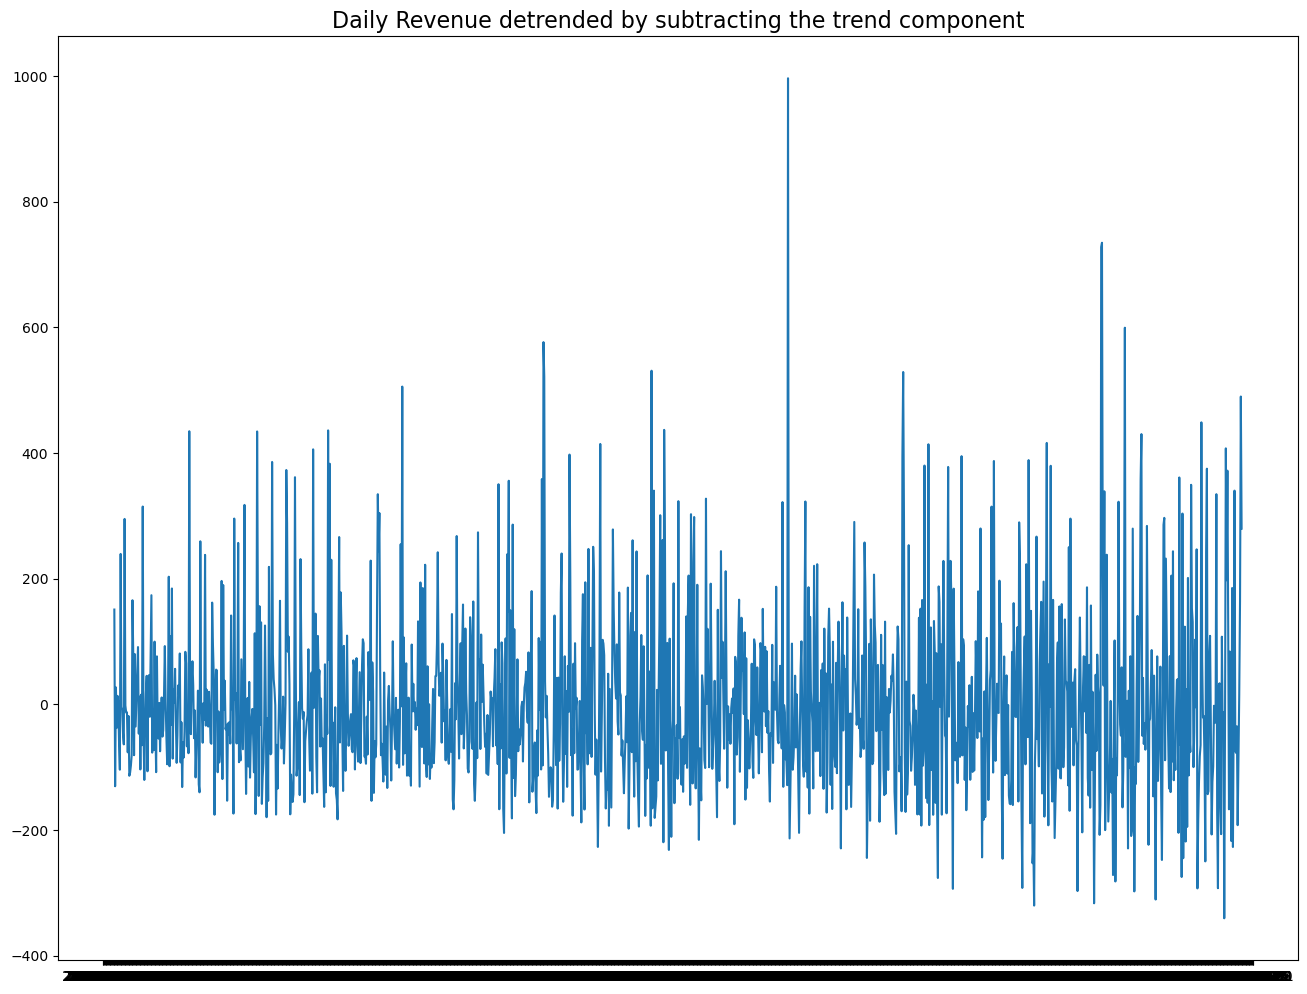

In [26]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=30)
detrended = CA_only["Revenue"].values - result_mul.trend
plt.plot(detrended)
plt.title('Daily Revenue detrended by subtracting the trend component', fontsize=16)

In [27]:
detrended_filtered = detrended[29:]
detrended_filtered = detrended_filtered[:-15]

adf_result = adfuller(detrended_filtered)
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -12.198278452576526
P-value: 1.240023078755318e-22


### Deseasonalizing Temperature

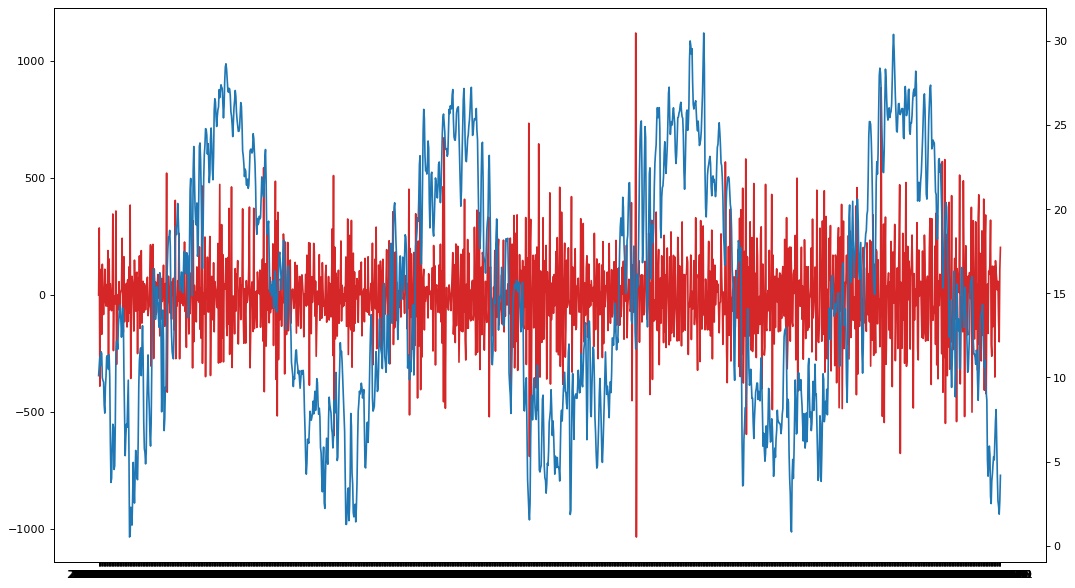

In [28]:
CA_plot = CA_only.reset_index()

fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(CA_plot["Order Date"],
            CA_plot["first_oder_diff"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(CA_plot["Order Date"],
         CA_plot["tavg"],
         color="tab:blue")


In [29]:
CA_only["Temp_No_Season"] = CA_only["tavg"] - CA_only["tavg"].shift(12*30)

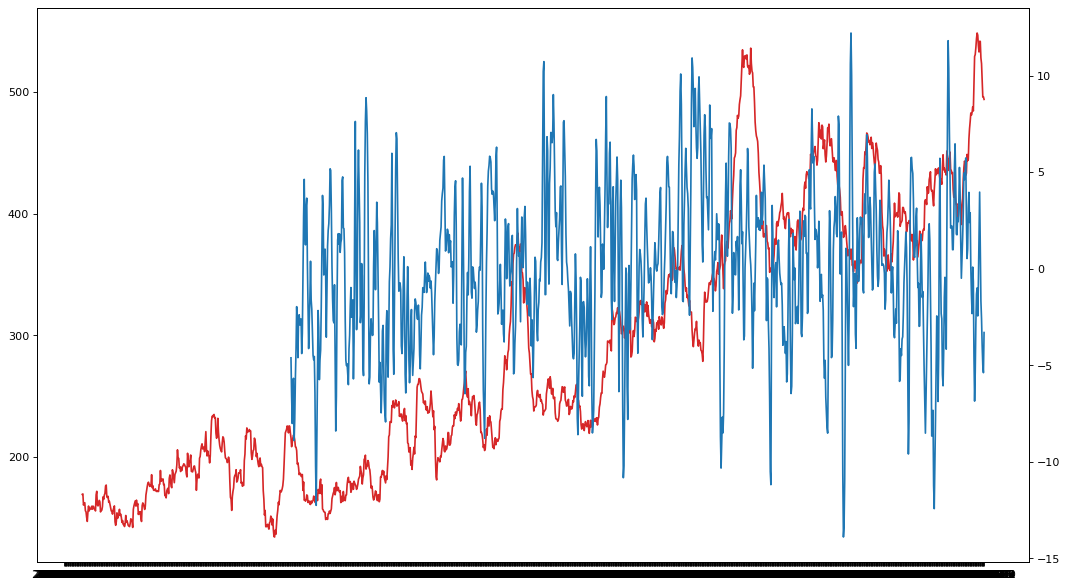

In [31]:
CA_plot = CA_only.reset_index()

fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(CA_plot["Order Date"],
            CA_plot["Revenue_SMA30"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(CA_plot["Order Date"],
         CA_plot["Temp_No_Season"],
         color="tab:blue")
